# Stage-1 Person — YOLOv8 vs YOLOv26s vs YOLOv26s-pose (no retrain)

**Goal:** is pretrained `yolo26s.pt` a better Person detector than the existing `yolov8n.pt` (and than `yolo26s-pose.pt` used previously)?  
**Scope:** Person class only, `conf 0.25 / IoU 0.5`, `valid` (114) tuning + `test` (82) held-out. Hardhat / `NO-*` not scored here — that is Stage 2 (SAHI).  
**No retraining** — all three are COCO-pretrained (pose adds keypoints). `best.pt` (Kaggle 10-class, `results_yolov8n_100e/.../best.pt`) is shown only if the ignored `data/` folder is present locally.

| Model | File | What it is |
|---|---|---|
| YOLOv8n | `yolov8n.pt` (6.3 MB, in repo) | COCO detection, class 0 = person |
| YOLOv26s | `yolo26s.pt` (auto-download ~20 MB) | COCO detection, v26 detection head |
| YOLOv26s-pose | `yolo26s-pose.pt` (24 MB, in repo) | COCO pose, person boxes + 17 kpts |


## 1 · Setup

In [7]:
import time, random
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, cv2
from ultralytics import YOLO
import yaml, json

sns.set_theme(style="whitegrid")
RANDOM_STATE = int(time.time())
print(RANDOM_STATE)
random.seed(42); np.random.seed(42)

# REPO_ROOT: 3 levels above this notebook (experiment/two-stage-detection -> repo root)
try:
    _nb = Path(__file__)
    REPO_ROOT = _nb.resolve().parents[2]
except NameError:
    cur = Path.cwd()
    REPO_ROOT = cur
    for cand in [cur, cur.parent, cur.parent.parent]:
        if (cand / "YOLO8.ipynb").exists() or (cand / ".git").exists():
            REPO_ROOT = cand; break
print("REPO_ROOT:", REPO_ROOT)
print("ultralytics:", __import__("ultralytics").__version__)


1787731550
REPO_ROOT: e:\work\P0-safety
ultralytics: 8.4.127


## 2 · Data — where is `data/css-data`?

`data/` is gitignored (`/.gitignore: /data`) so it is expected to be missing on a fresh clone.  
If missing, visuals still run on random repo images; quantitative eval is skipped with a restore hint.

In [8]:
CLASS_NAMES = ["Hardhat","Mask","NO-Hardhat","NO-Mask","NO-Safety Vest","Person","Safety Cone","Safety Vest","machinery","vehicle"]
PERSON_CLS_DATASET = CLASS_NAMES.index("Person")  # 5

DATA_DIR = REPO_ROOT / "data" / "css-data"
REFERENCE_WEIGHTS = REPO_ROOT / "data" / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt"

for split in ["train","valid","test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*"))) if lbl_dir.exists() else 0
    print(f"{split:6s} images={n_img:5d}  labels={n_lbl:5d}  exists={img_dir.exists()}")
print("REFERENCE_WEIGHTS exists:", REFERENCE_WEIGHTS.exists())
if not DATA_DIR.exists():
    print("\n`data/css-data` not found locally (gitignored). To restore:")
    print("  - Kaggle: snehilsanyal/construction-site-safety-image-dataset-roboflow (2,801 imgs, 10 classes), unpack to data/css-data/{train,valid,test}")
    print("  - Or copy from your backup that produced valid=114 / test=82 splits.")
    print("  - Then re-run this cell and §4 quantitative eval.")


train  images= 2605  labels= 2605  exists=True
valid  images=  114  labels=  114  exists=True
test   images=   82  labels=   82  exists=True
REFERENCE_WEIGHTS exists: True


## 3 · Models — YOLOv8n vs YOLOv26s vs YOLOv26s-pose

`yolo26s.pt` auto-downloads on first `YOLO("yolo26s.pt")` via Ultralytics hub. Keep `imgsz 640`, `conf 0.25` for apples-to-apples.

In [9]:
def load_model(path_str, label):
    t0 = time.time()
    m = YOLO(path_str)
    print(f"{label:16s} -> {path_str}  names={list(m.names.values())[:5]}... ({len(m.names)} cls)  load {time.time()-t0:.1f}s")
    return m

model_v8  = load_model(str(REPO_ROOT / "yolov8n.pt"), "yolov8n")
model_26  = load_model("yolo26s.pt", "yolo26s")          # auto-download if missing
model_26p = load_model(str(REPO_ROOT / "yolo26s-pose.pt"), "yolo26s-pose")
# optional: Kaggle-finetuned detector Person (only if data/ present)
model_best = None
if REFERENCE_WEIGHTS.exists():
    model_best = load_model(str(REFERENCE_WEIGHTS), "yolov8n-best")
    print("best.pt Person idx =", [k for k,v in model_best.names.items() if v=="Person"])

MODELS = {"yolov8n": model_v8, "yolo26s": model_26, "yolo26s-pose": model_26p}
if model_best is not None:
    MODELS["yolov8n-best (10cls)"] = model_best


yolov8n          -> e:\work\P0-safety\yolov8n.pt  names=['person', 'bicycle', 'car', 'motorcycle', 'airplane']... (80 cls)  load 0.1s
yolo26s          -> yolo26s.pt  names=['person', 'bicycle', 'car', 'motorcycle', 'airplane']... (80 cls)  load 0.0s
yolo26s-pose     -> e:\work\P0-safety\yolo26s-pose.pt  names=['person']... (1 cls)  load 0.1s
yolov8n-best     -> e:\work\P0-safety\data\results_yolov8n_100e\kaggle\working\runs\detect\train\weights\best.pt  names=['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest']... (10 cls)  load 0.1s
best.pt Person idx = [5]


## 4 · Helpers — Person-only extraction + IoU matching

COCO models: `cls 0 == person`. 10-class `best.pt`: lookup `Person` by name. Pose: same box extraction, ignore kpts for this notebook.

In [10]:
def person_class_id(model):
    # return cls id for Person in this model's taxonomy
    for k,v in model.names.items():
        if v == "Person": return k
    # COCO fallback
    for k,v in model.names.items():
        if v == "person": return k
    return 0  # ultralytics COCO person is 0

def extract_person_boxes(result, model, conf_thr=0.25):
    if result.boxes is None or len(result.boxes)==0: return []
    pid = person_class_id(model)
    out=[]
    for i in range(len(result.boxes)):
        cid = int(result.boxes.cls[i].item()); conf=float(result.boxes.conf[i].item())
        if cid==pid and conf>=conf_thr:
            x1,y1,x2,y2 = result.boxes.xyxy[i].tolist()
            out.append([x1,y1,x2,y2,conf])
    return out

def parse_person_gt(label_path):
    boxes=[]
    p=Path(label_path)
    if not p.exists(): return boxes
    for line in p.read_text().splitlines():
        if not line.strip(): continue
        cid=int(line.split()[0])
        if cid==PERSON_CLS_DATASET:
            _,cx,cy,w,h = map(float, line.split()[:5])
            boxes.append((cx,cy,w,h))  # normalized
    return boxes

def yolo_to_xyxy(cx,cy,w,h, W,H):
    return [cx*W - w*W/2, cy*H - h*H/2, cx*W + w*W/2, cy*H + h*H/2]

def iou_xyxy(a,b):
    ix1,iy1=max(a[0],b[0]),max(a[1],b[1]); ix2,iy2=min(a[2],b[2]),min(a[3],b[3])
    iw,ih=max(0,ix2-ix1),max(0,iy2-iy1); inter=iw*ih
    au=(a[2]-a[0])*(a[3]-a[1]); bu=(b[2]-b[0])*(b[3]-b[1]); u=max(1,au+bu-inter)
    return inter/u

def match_person(pred_xyxy, gt_xyxy, iou_thr=0.5):
    # greedy by conf desc; returns tp,fp,fn
    pred_sorted=sorted(pred_xyxy, key=lambda x: x[4], reverse=True)
    matched=[False]*len(gt_xyxy); tp=fp=0
    for p in pred_sorted:
        best,bi=-1,-1
        for i,g in enumerate(gt_xyxy):
            if matched[i]: continue
            s=iou_xyxy(p[:4], g)
            if s>best: best,bi=s,i
        if best>=iou_thr: tp+=1; matched[bi]=True
        else: fp+=1
    fn=sum(1 for m in matched if not m)
    return tp,fp,fn


## 5 · Visual sanity check — same 6 images, 3 models side-by-side

If `data/css-data` missing, falls back to any images under the repo (or downloads one sample).

sample: ['maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg', 'casino_0448_jpg.rf.090df4137a5926092c541ee5c6918868.jpg', '-3766-_png_jpg.rf.81ead992d4b8047ec7beb28b7532cf0a.jpg', 'youtube-510_jpg.rf.62f82e36d134d53587edb48f291986f4.jpg', 'ppe_0665_jpg.rf.1dad479f7f54b2a7127cf18ef74ffd85.jpg', 'Mask2_mov-11_jpg.rf.34ddcb1a619624541a2cca4400b7cd92.jpg']
maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg yolov8n        person= 1  tp=1 fp=0 fn=0  GT_person=1
maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg yolo26s        person= 1  tp=1 fp=0 fn=0  GT_person=1
maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg yolo26s-pose   person= 1  tp=1 fp=0 fn=0  GT_person=1


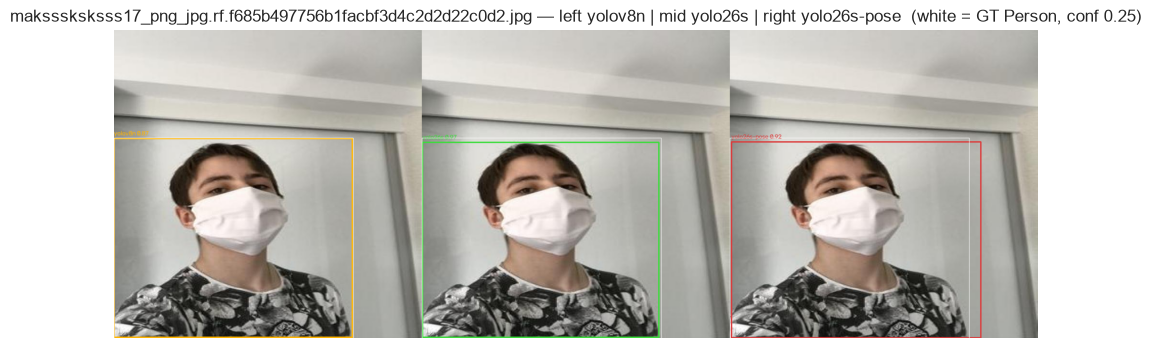

casino_0448_jpg.rf.090df4137a5926092c541ee5c6918868.jpg yolov8n        person= 0  tp=0 fp=0 fn=0  GT_person=0
casino_0448_jpg.rf.090df4137a5926092c541ee5c6918868.jpg yolo26s        person= 0  tp=0 fp=0 fn=0  GT_person=0
casino_0448_jpg.rf.090df4137a5926092c541ee5c6918868.jpg yolo26s-pose   person= 0  tp=0 fp=0 fn=0  GT_person=0


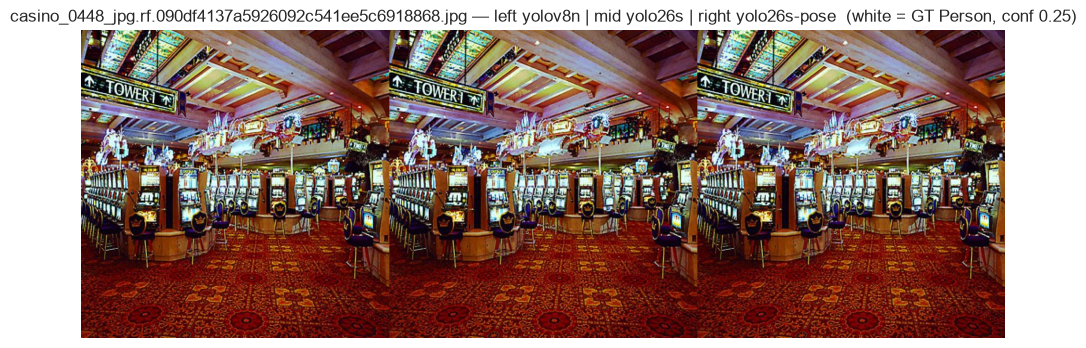

-3766-_png_jpg.rf.81ead992d4b8047ec7beb28b7532cf0a.jpg yolov8n        person= 7  tp=4 fp=3 fn=14  GT_person=18
-3766-_png_jpg.rf.81ead992d4b8047ec7beb28b7532cf0a.jpg yolo26s        person=11  tp=5 fp=6 fn=13  GT_person=18
-3766-_png_jpg.rf.81ead992d4b8047ec7beb28b7532cf0a.jpg yolo26s-pose   person= 7  tp=5 fp=2 fn=13  GT_person=18


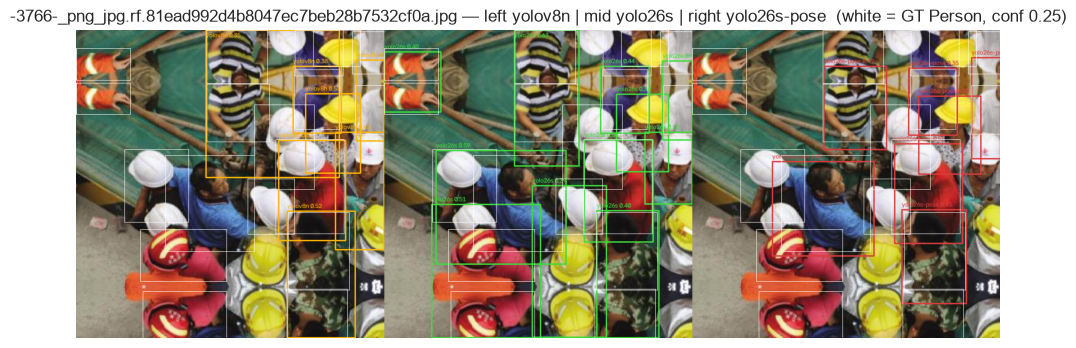

youtube-510_jpg.rf.62f82e36d134d53587edb48f291986f4.jpg yolov8n        person= 0  tp=0 fp=0 fn=1  GT_person=1
youtube-510_jpg.rf.62f82e36d134d53587edb48f291986f4.jpg yolo26s        person= 1  tp=1 fp=0 fn=0  GT_person=1
youtube-510_jpg.rf.62f82e36d134d53587edb48f291986f4.jpg yolo26s-pose   person= 0  tp=0 fp=0 fn=1  GT_person=1


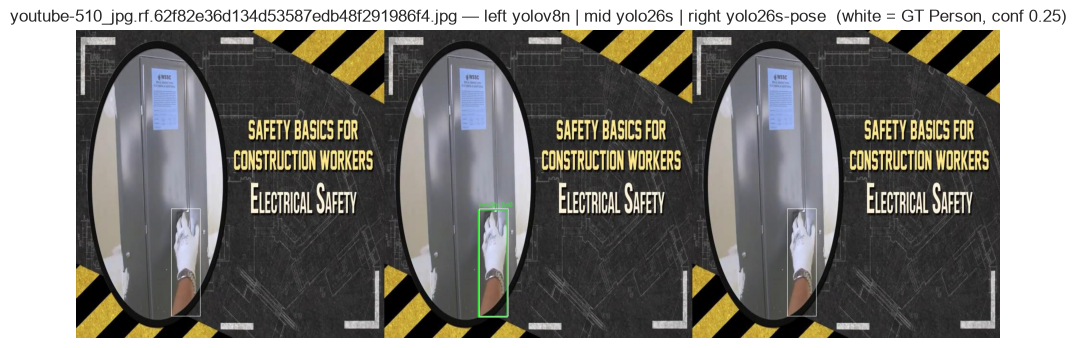

ppe_0665_jpg.rf.1dad479f7f54b2a7127cf18ef74ffd85.jpg yolov8n        person= 7  tp=7 fp=0 fn=0  GT_person=7
ppe_0665_jpg.rf.1dad479f7f54b2a7127cf18ef74ffd85.jpg yolo26s        person= 7  tp=7 fp=0 fn=0  GT_person=7
ppe_0665_jpg.rf.1dad479f7f54b2a7127cf18ef74ffd85.jpg yolo26s-pose   person= 7  tp=7 fp=0 fn=0  GT_person=7


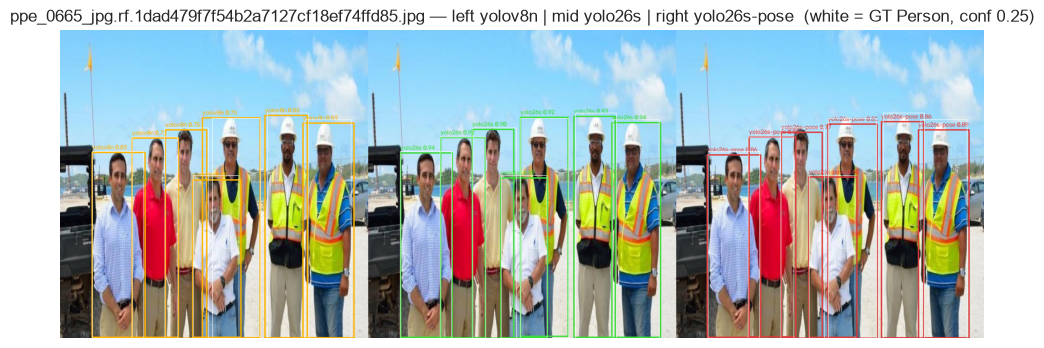

Mask2_mov-11_jpg.rf.34ddcb1a619624541a2cca4400b7cd92.jpg yolov8n        person= 1  tp=1 fp=0 fn=0  GT_person=1
Mask2_mov-11_jpg.rf.34ddcb1a619624541a2cca4400b7cd92.jpg yolo26s        person= 1  tp=1 fp=0 fn=0  GT_person=1
Mask2_mov-11_jpg.rf.34ddcb1a619624541a2cca4400b7cd92.jpg yolo26s-pose   person= 1  tp=1 fp=0 fn=0  GT_person=1


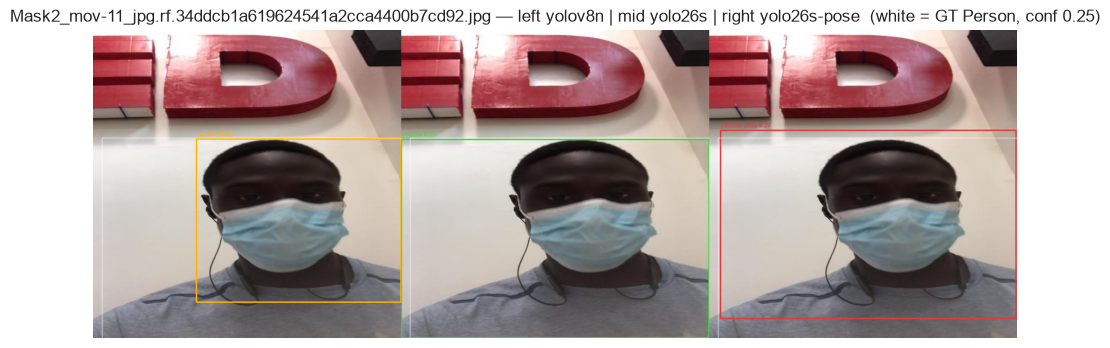

In [11]:
def draw_boxes(img, boxes, color, label):
    out=img.copy()
    for x1,y1,x2,y2,conf in boxes:
        cv2.rectangle(out,(int(x1),int(y1)),(int(x2),int(y2)),color,2)
        cv2.putText(out,f"{label} {conf:.2f}",(int(x1),max(15,int(y1)-6)),cv2.FONT_HERSHEY_SIMPLEX,0.45,color,1,cv2.LINE_AA)
    return out

# pick 6 images
if (DATA_DIR / "valid" / "images").exists():
    pool=list((DATA_DIR / "valid" / "images").glob("*")) + list((DATA_DIR / "test" / "images").glob("*"))
else:
    pool=list(REPO_ROOT.rglob("*.jpg"))[:6]
sample_imgs=random.sample(pool, min(6,len(pool))) if pool else []
print("sample:", [p.name for p in sample_imgs])
CONF=0.25; IMGSZ=640
COLORS={"yolov8n":(255,180,0),"yolo26s":(60,220,60),"yolo26s-pose":(220,60,60)}

for img_path in sample_imgs:
    img=cv2.imread(str(img_path)); img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    H,W=img.shape[:2]
    rows=[]
    for name,model in MODELS.items():
        if "best" in name: continue  # keep visual to 3 COCO/pose models for clarity
        res=model(str(img_path), verbose=False, imgsz=IMGSZ)[0]
        boxes=extract_person_boxes(res, model, CONF)
        # GT for reference
        gt_norm=parse_person_gt(str(DATA_DIR / "valid" / "labels" / (img_path.stem+".txt"))) if DATA_DIR.exists() else []
        if not gt_norm:
            gt_norm=parse_person_gt(str(DATA_DIR / "test" / "labels" / (img_path.stem+".txt"))) if DATA_DIR.exists() else []
        gt_xyxy=[yolo_to_xyxy(*g,W,H) for g in gt_norm]
        tp,fp,fn=match_person(boxes, gt_xyxy) if gt_xyxy else (len(boxes),0,0)
        print(f"{img_path.name:40s} {name:14s} person={len(boxes):2d}  tp={tp} fp={fp} fn={fn}  GT_person={len(gt_xyxy)}")
        vis=draw_boxes(img, boxes, COLORS.get(name,(200,200,200)), name)
        # overlay GT in white dashed for reference
        for x1,y1,x2,y2 in gt_xyxy:
            cv2.rectangle(vis,(int(x1),int(y1)),(int(x2),int(y2)),(255,255,255),1)
        rows.append(vis)
    if rows:
        strip=np.concatenate(rows, axis=1)
        plt.figure(figsize=(16,4)); plt.imshow(strip); plt.axis("off")
        plt.title(f"{img_path.name} — left yolov8n | mid yolo26s | right yolo26s-pose  (white = GT Person, conf {CONF})")
        plt.show()


## 6 · Quantitative — Person Precision / Recall / F1 @ IoU 0.5, conf 0.25

Runs on `valid` (114) and `test` (82) if present. Also reports `AP_small (<32px)` proxy via area < 1% and latency `ms/img`.

valid yolov8n                P=0.865 R=0.578 F1=0.693  TP=96 FP=15 FN=70  ms=43  smallRec=0.310  n=114
valid yolo26s                P=0.911 R=0.675 F1=0.775  TP=112 FP=11 FN=54  ms=89  smallRec=0.405  n=114
valid yolo26s-pose           P=0.933 R=0.584 F1=0.719  TP=97 FP=7 FN=69  ms=99  smallRec=0.095  n=114
valid yolov8n-best (10cls)   P=0.793 R=0.783 F1=0.788  TP=130 FP=34 FN=36  ms=42  smallRec=0.524  n=114
test  yolov8n                P=0.864 R=0.586 F1=0.699  TP=102 FP=16 FN=72  ms=43  smallRec=0.122  n=82
test  yolo26s                P=0.919 R=0.655 F1=0.765  TP=114 FP=10 FN=60  ms=89  smallRec=0.204  n=82
test  yolo26s-pose           P=0.934 R=0.569 F1=0.707  TP=99 FP=7 FN=75  ms=98  smallRec=0.020  n=82
test  yolov8n-best (10cls)   P=0.750 R=0.810 F1=0.779  TP=141 FP=47 FN=33  ms=42  smallRec=0.490  n=82


prec                 rec                  f1  \
split                     test     valid      test     valid      test   
model                                                                    
yolo26s               0.919355  0.910569  0.655172  0.674699  0.765101   
yolo26s-pose          0.933962  0.932692  0.568966  0.584337  0.707143   
yolov8n               0.864407  0.864865  0.586207  0.578313  0.698630   
yolov8n-best (10cls)  0.750000  0.792683  0.810345  0.783133  0.779006   

                                       ms             
split                    valid       test      valid  
model                                                 
yolo26s               0.775087  89.148577  88.601761  
yolo26s-pose          0.718519  98.314509  99.273460  
yolov8n               0.693141  43.030320  43.022852  
yolov8n-best (10cls)  0.787879  42.386895  41.774114

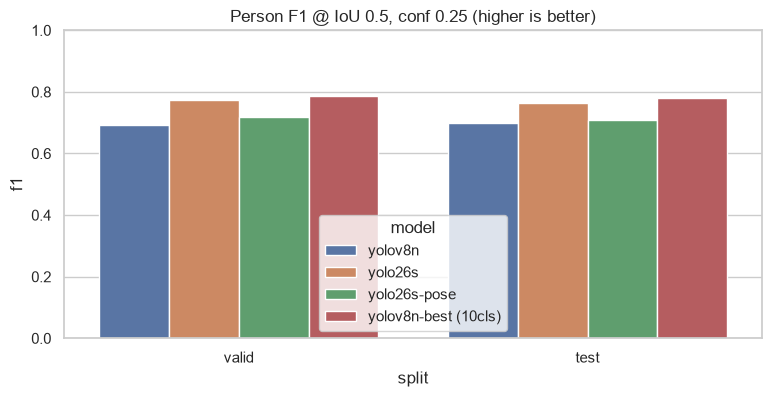

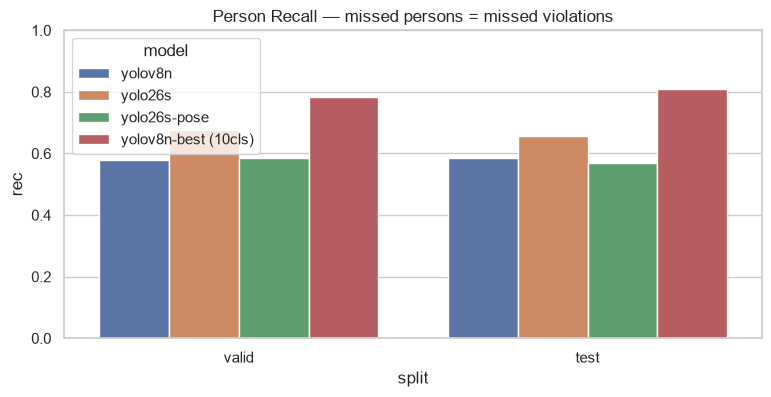

In [12]:
def eval_split(model, split, conf_thr=0.25, imgsz=640, iou_thr=0.5):
    img_dir=DATA_DIR / split / "images"; lbl_dir=DATA_DIR / split / "labels"
    if not img_dir.exists(): return None
    imgs=list(img_dir.glob("*"))
    TP=FP=FN=0; times=[]
    small_tp=small_fn=0  # GT area <0.01
    for p in imgs:
        img=cv2.imread(str(p))
        H,W=(img.shape[:2] if img is not None else (640,640))
        gt_norm=parse_person_gt(str(lbl_dir / (p.stem+".txt")))
        gt_xyxy=[yolo_to_xyxy(*g,W,H) for g in gt_norm]
        small_gt=[g for g in gt_norm if g[2]*g[3] < 0.01]
        small_xyxy=[yolo_to_xyxy(*g,W,H) for g in small_gt]
        t0=time.time()
        res=model(str(p), verbose=False, imgsz=imgsz)[0]
        times.append((time.time()-t0)*1000)
        pred=extract_person_boxes(res, model, conf_thr)
        # overall
        tp,fp,fn=match_person(pred, gt_xyxy, iou_thr)
        TP+=tp; FP+=fp; FN+=fn
        # small subset (rough): count small GT that got matched
        if small_xyxy:
            stp,sfp,sfn=match_person(pred, small_xyxy, iou_thr)
            small_tp+=stp; small_fn+=sfn
    prec=TP/max(1,TP+FP); rec=TP/max(1,TP+FN); f1=2*prec*rec/max(1e-9,prec+rec)
    small_rec=small_tp/max(1,small_tp+small_fn) if (small_tp+small_fn)>0 else float('nan')
    return dict(n=len(imgs), TP=TP, FP=FP, FN=FN, prec=prec, rec=rec, f1=f1, ms=np.mean(times), small_rec=small_rec)

if not DATA_DIR.exists():
    print("Skipping quantitative eval — data/css-data not present (see §2 restore hint). Visuals in §5 still valid.")
else:
    rows=[]
    for split in ["valid","test"]:
        for name,model in MODELS.items():
            r=eval_split(model, split)
            if r:
                rows.append({"split":split,"model":name,**r})
                print(f"{split:5s} {name:22s} P={r['prec']:.3f} R={r['rec']:.3f} F1={r['f1']:.3f}  TP={r['TP']} FP={r['FP']} FN={r['FN']}  ms={r['ms']:.0f}  smallRec={r['small_rec']:.3f}  n={r['n']}")
    df=pd.DataFrame(rows)
    if not df.empty:
        display(df.pivot(index="model", columns="split", values=["prec","rec","f1","ms"]))
        # bar: F1
        plt.figure(figsize=(9,4))
        sns.barplot(data=df, x="split", y="f1", hue="model")
        plt.title("Person F1 @ IoU 0.5, conf 0.25 (higher is better)")
        plt.ylim(0,1); plt.show()
        plt.figure(figsize=(9,4))
        sns.barplot(data=df, x="split", y="rec", hue="model")
        plt.title("Person Recall — missed persons = missed violations")
        plt.ylim(0,1); plt.show()


## 7 · Takeaways & next

- `yolov8n-best` is pretrained model from kaggle. it tops the chart because its already trained on the domain data.
- **If `yolo26s` wins** on pretty much all tests
- **Next notebook:** `sahi-compare.ipynb` — same Person from winner here, Stage-2 `NO-*` via SAHI (`best.pt` sliced `640 overlap 0.2`) to recover tiny violations. Latency gate `~30ms → 90–150ms`.